In [1]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import root_scalar, minimize_scalar
import copy

# ── PARAMETERS ──────────────────────────────────────────────────────────────

@dataclass
class Parameters:
    beta: float = 0.99**30
    gamma: float = 2.1
    phi: float = 0.5
    alpha: float = 0.36
    delta: float = 1.0 - (1 - 0.06)**30
    z: float = 1.0
    tau: float = 0.3
    tau_a: float = 0.0
    tau_a_iid: float = 0.0
    pi_a: float = 0.0
    Nw: float = 0.8
    Nk: float = 0.2

In [2]:
# ── PRICES & OUTPUT ─────────────────────────────────────────────────────────

def compute_prices_output(K, par: Parameters):
    """Return factor prices and output for a given capital stock."""
    L = par.Nw / 2
    k = K / L
    r = par.alpha * par.z * k ** (par.alpha - 1) - par.delta
    w = (1 - par.alpha) * par.z * k**par.alpha
    Y = par.z * K**par.alpha * L**(1 - par.alpha)
    return r, w, Y

In [3]:
# ── PART 1: EULER EQUATION ERROR ────────────────────────────────────────────

def euler_err(K_next, K, par: Parameters):
    """Compute the capitalists' Euler equation error."""
    r, *_ = compute_prices_output(K, par)
    r_next, *_ = compute_prices_output(K_next, par)

    bequests = par.phi * (1 - par.tau_a) * (1 + r) * K / (par.Nk / 2)
    a = K_next / (par.Nk / 2)

    wealth_tax = par.tau_a * (1 + r) * K
    transfers = wealth_tax

    c_y = np.fmax(bequests + transfers - a, 1e-10)

    wealth_tax_next = par.tau_a * (1 + r_next) * K_next
    transfers_next = wealth_tax_next

    c_o = (1 - par.tau_a) * (1 - par.phi) * (1 + r_next) * a + transfers_next

    lhs = c_y ** (-par.gamma)
    dfact = par.beta * (1 - par.tau_a) * (1 - par.phi) * (1 + r_next)
    rhs = dfact * c_o ** (-par.gamma)

    return lhs - rhs

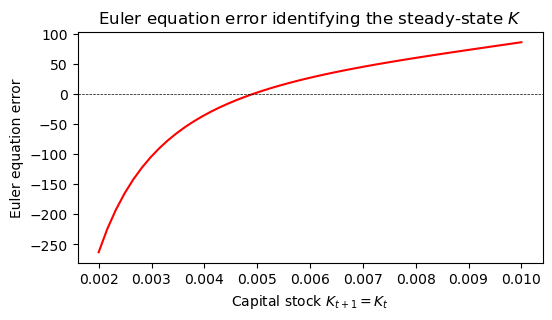

In [4]:
# Plot Euler equation errors
par = Parameters()
K_grid = np.linspace(0.002, 0.01)
ee_grid = [euler_err(K, K, par) for K in K_grid]

plt.figure(figsize=(6, 3))
plt.plot(K_grid, ee_grid, c='red')
plt.axhline(0, c='black', lw=0.5, ls='--')
plt.ylabel('Euler equation error')
plt.xlabel('Capital stock $K_{t+1} = K_t$')
plt.title('Euler equation error identifying the steady-state $K$')
plt.show()

In [5]:
# ── PART 2: STEADY STATE ────────────────────────────────────────────────────

@dataclass
class SteadyState:
    par: Parameters = None
    c_wy: float = None
    c_wo: float = None
    c_ky: float = None
    c_ko: float = None
    a: float = None
    b: float = None
    s: float = None
    wealth_tax: float = None
    p: float = None
    r: float = None
    w: float = None
    K: float = None
    Y: float = None

In [6]:
def worker_allocation(w, transfers, par: Parameters):
    """Return consumption of young and old workers."""
    income = (1 - par.tau) * w
    c_wy = income + transfers
    p = par.tau * w
    c_wo = p + transfers
    return c_wy, c_wo


def capitalist_allocation(K, K_next, r, transfers, par: Parameters):
    """Return consumption, savings, bequests, and savings rate of capitalists."""
    a = K_next / (par.Nk / 2)
    b = par.phi * (1 - par.tau_a) * (1 + r) * K / (par.Nk / 2)
    s = a / (b + transfers)
    c_ky = b + transfers - a
    a_prev = K / (par.Nk / 2)
    c_ko = (1 - par.tau_a) * (1 - par.phi) * (1 + r) * a_prev + transfers
    return c_ky, c_ko, a, b, s

In [7]:
def compute_steady_state(par: Parameters, euler_func=euler_err):
    """Compute the steady state of the OLG model."""
    bracket = (0.001, 1)
    res = root_scalar(lambda K: euler_func(K, K, par), bracket=bracket)

    if not res.converged:
        raise ValueError(f'Root-finder failed to converge: {res.flag}')

    eq = SteadyState(par=par, K=res.root)
    eq.r, eq.w, eq.Y = compute_prices_output(eq.K, par)

    eq.wealth_tax = par.tau_a * (1 + eq.r) * eq.K
    transfers = eq.wealth_tax

    eq.c_ky, eq.c_ko, eq.a, eq.b, eq.s = capitalist_allocation(
        eq.K, eq.K, eq.r, transfers, par
    )
    eq.c_wy, eq.c_wo = worker_allocation(eq.w, transfers, par)
    eq.p = par.tau * eq.w

    demand_w = 0.5 * par.Nw * (eq.c_wy + eq.c_wo)
    demand_k = 0.5 * par.Nk * (eq.c_ky + eq.c_ko + eq.a)
    supply = eq.Y + (1 - par.delta) * eq.K
    assert abs(demand_w + demand_k - supply) < 1.0e-8

    return eq


def print_steady_state(eq: SteadyState):
    """Print equilibrium prices, allocations, and market clearing."""
    print('Steady state equilibrium:')
    print(' Worker Households:')
    print(f'  c_y = {eq.c_wy:.5f}')
    print(f'  c_o = {eq.c_wo:.5f}')
    print(' Capitalist Households:')
    print(f'  c_y = {eq.c_ky:.5f}')
    print(f'  c_o = {eq.c_ko:.5f}')
    print(f'  b   = {eq.b:.5f}')
    print(f'  a   = {eq.a:.5f}')
    print(f'  s   = {eq.s:.5f}')
    print(' Firms:')
    print(f'  K   = {eq.K:.5f}')
    print(f'  L   = {eq.par.Nw / 2:.5f}')
    print(f'  Y   = {eq.Y:.5f}')
    print(' Government:')
    print(f'  p          = {eq.p:.5f}')
    print(f'  transfers  = {eq.wealth_tax:.5f}')
    print(f'  wealth tax = {eq.wealth_tax/eq.Y:.3%} of GDP')
    print(' Prices:')
    print(f'  r = {eq.r:.5f}')
    print(f'  w = {eq.w:.5f}')
    print(' Market clearing:')
    print(f'  Capital: {eq.K - eq.a * eq.par.Nk * 0.5:.5e}')
    demand_w = 0.5 * eq.par.Nw * (eq.c_wy + eq.c_wo)
    demand_k = 0.5 * eq.par.Nk * (eq.c_ky + eq.c_ko + eq.a)
    print(f'  Goods:   {demand_w + demand_k - eq.Y - (1 - eq.par.delta) * eq.K:.5e}')

In [8]:
# Compute and report steady state
par = Parameters()
eq = compute_steady_state(par)
print_steady_state(eq)

# Annualized interest rate
annualized_r = (1 + eq.r) ** (1/30) - 1
print(f'\nAnnualized interest rate: {annualized_r:.2%}')

Steady state equilibrium:
 Worker Households:
  c_y = 0.09198
  c_o = 0.03942
 Capitalist Households:
  c_y = 0.10246
  c_o = 0.15168
  b   = 0.15168
  a   = 0.04922
  s   = 0.32452
 Firms:
  K   = 0.00492
  L   = 0.40000
  Y   = 0.08213
 Government:
  p          = 0.03942
  transfers  = 0.00000
  wealth tax = 0.000% of GDP
 Prices:
  r = 5.16294
  w = 0.13141
 Market clearing:
  Capital: 0.00000e+00
  Goods:   -4.98733e-18

Annualized interest rate: 6.25%


In [9]:
# ── PART 3: TRANSITION DYNAMICS ─────────────────────────────────────────────

@dataclass
class Simulation:
    par: Parameters = None
    c_wy: np.ndarray = None
    c_wo: np.ndarray = None
    c_ky: np.ndarray = None
    c_ko: np.ndarray = None
    a: np.ndarray = None
    b: np.ndarray = None
    s: np.ndarray = None
    wealth_tax: np.ndarray = None
    r: np.ndarray = None
    w: np.ndarray = None
    K: np.ndarray = None
    Y: np.ndarray = None


def initialize_sim(T):
    """Initialize simulation instance and allocate arrays."""
    sim = Simulation()
    for attr in ['c_wy','c_wo','c_ky','c_ko','a','b','s','wealth_tax','r','w','K','Y']:
        setattr(sim, attr, np.empty(T))
    return sim

In [10]:
def simulate_olg(K0, T, par: Parameters, euler_func=euler_err):
    """Simulate transition dynamics of the OLG model."""
    sim = initialize_sim(T)
    sim.par = par

    for t in range(T):
        sim.K[t] = K0 if t == 0 else sim.a[t-1] * (par.Nk / 2)
        K = sim.K[t]

        sim.r[t], sim.w[t], sim.Y[t] = compute_prices_output(K, par)

        res = root_scalar(euler_func, bracket=(0.1*K, 5*K), args=(K, par))
        if not res.converged:
            print(f'Root-finder did not converge at t={t}')
        K_next = res.root

        sim.wealth_tax[t] = par.tau_a * (1 + sim.r[t]) * K
        transfers = sim.wealth_tax[t]

        sim.c_ky[t], sim.c_ko[t], sim.a[t], sim.b[t], sim.s[t] = \
            capitalist_allocation(K, K_next, sim.r[t], transfers, par)
        sim.c_wy[t], sim.c_wo[t] = worker_allocation(sim.w[t], transfers, par)

        demand_w = 0.5 * par.Nw * (sim.c_wy[t] + sim.c_wo[t])
        demand_k = 0.5 * par.Nk * (sim.c_ky[t] + sim.c_ko[t] + sim.a[t])
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]
        assert abs(demand_w + demand_k - supply) < 1.0e-8

    return sim

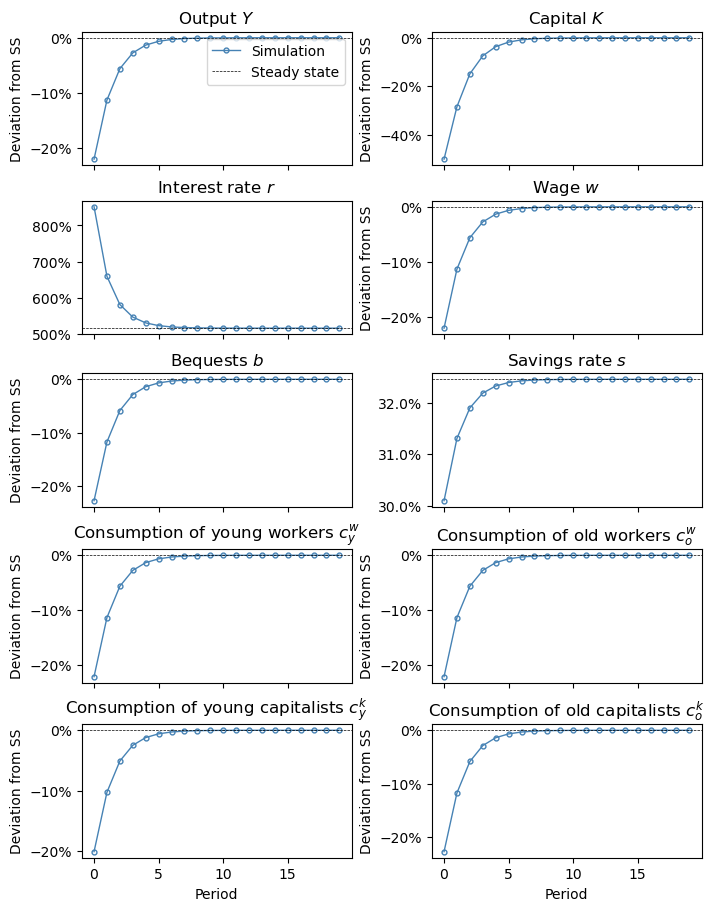

In [11]:
def plot_simulation(eq, sim, eq_new=None):
    """Plot simulated time series of the OLG model."""
    fig, axes = plt.subplots(5, 2, figsize=(7, 9), sharex=True,
                             constrained_layout=True)

    kwargs = dict(marker='o' if len(sim.K) < 30 else None, markersize=3.5,
                  color='steelblue', linewidth=1.0, mfc='none', mew=1.0)
    kwargs_ss = dict(color='black', linewidth=0.5, linestyle='--',
                     label='Steady state' if eq_new is None else 'Old steady state')
    kwargs_new = dict(color='red', linewidth=0.5, linestyle='--',
                      label='New steady state')

    ylabel = 'Deviation from old SS' if eq_new is not None else 'Deviation from SS'

    panels = [
        (axes[0,0], sim.Y/eq.Y-1,     None if eq_new is None else eq_new.Y/eq.Y-1,   'Output $Y$',                        ylabel),
        (axes[0,1], sim.K/eq.K-1,     None if eq_new is None else eq_new.K/eq.K-1,   'Capital $K$',                       ylabel),
        (axes[1,0], sim.r,             None if eq_new is None else eq_new.r,           'Interest rate $r$',                 None),
        (axes[1,1], sim.w/eq.w-1,     None if eq_new is None else eq_new.w/eq.w-1,   'Wage $w$',                          ylabel),
        (axes[2,0], sim.b/eq.b-1,     None if eq_new is None else eq_new.b/eq.b-1,   'Bequests $b$',                      ylabel),
        (axes[2,1], sim.s,             None if eq_new is None else eq_new.s,           'Savings rate $s$',                  None),
        (axes[3,0], sim.c_wy/eq.c_wy-1, None if eq_new is None else eq_new.c_wy/eq.c_wy-1, r'Consumption of young workers $c_y^w$', ylabel),
        (axes[3,1], sim.c_wo/eq.c_wo-1, None if eq_new is None else eq_new.c_wo/eq.c_wo-1, r'Consumption of old workers $c_o^w$',   ylabel),
        (axes[4,0], sim.c_ky/eq.c_ky-1, None if eq_new is None else eq_new.c_ky/eq.c_ky-1, r'Consumption of young capitalists $c_y^k$', ylabel),
        (axes[4,1], sim.c_ko/eq.c_ko-1, None if eq_new is None else eq_new.c_ko/eq.c_ko-1, r'Consumption of old capitalists $c_o^k$',   ylabel),
    ]

    ss_values = [0, 0, eq.r, 0, 0, eq.s, 0, 0, 0, 0]

    for i, (ax, series, new_val, title, yl) in enumerate(panels):
        ax.plot(series, label='Simulation', **kwargs)
        ax.axhline(ss_values[i], **kwargs_ss)
        if eq_new is not None and new_val is not None:
            ax.axhline(new_val, **kwargs_new)
        ax.set_title(title)
        if yl:
            ax.set_ylabel(yl)
        if i == 0:
            ax.legend()

    # Savings rate: percent formatter
    axes[2,1].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))

    for ax in axes.flat:
        ylim = ax.get_ylim()
        dy = ylim[1] - ylim[0]
        decimals = 2 if dy < 0.01 else (1 if dy < 0.03 else 0)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=decimals))

    for ax in axes[-1]:
        ax.set_xlabel('Period')

    plt.show()


# Simulate and plot
T = 20
K0 = eq.K / 2
sim = simulate_olg(K0, T, par)
plot_simulation(eq, sim)

Steady state equilibrium:
 Worker Households:
  c_y = 0.09105
  c_o = 0.03986
 Capitalist Households:
  c_y = 0.09591
  c_o = 0.14163
  b   = 0.14015
  a   = 0.04572
  s   = 0.32283
 Firms:
  K   = 0.00457
  L   = 0.40000
  Y   = 0.07998
 Government:
  p          = 0.03839
  transfers  = 0.00148
  wealth tax = 1.845% of GDP
 Prices:
  r = 5.45335
  w = 0.12796
 Market clearing:
  Capital: 0.00000e+00
  Goods:   5.52943e-18


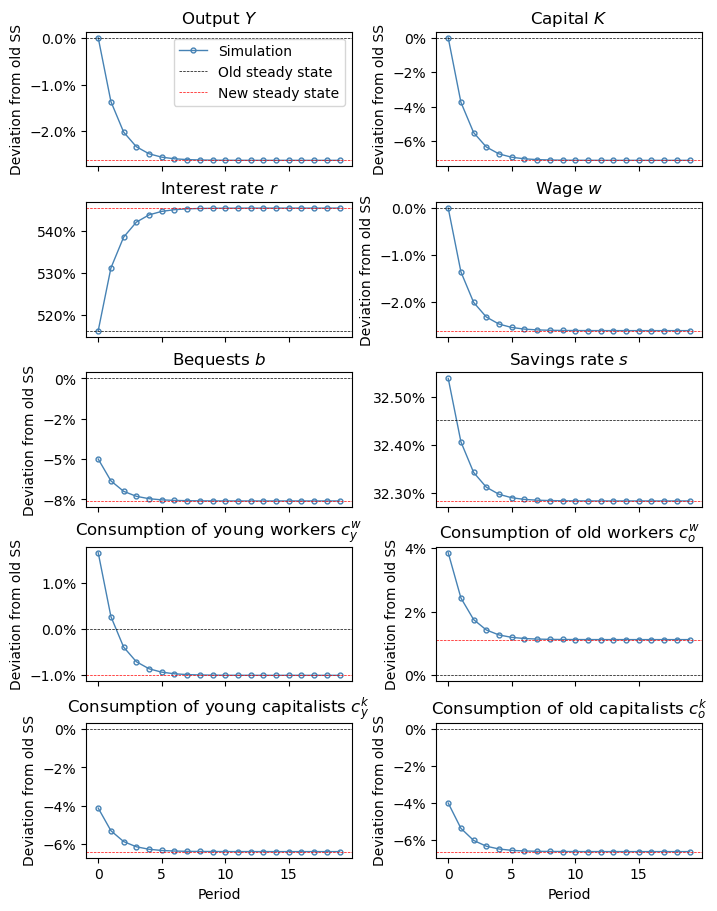

In [12]:
# ── PART 4: WEALTH TAX ──────────────────────────────────────────────────────

par_wtax = Parameters(tau_a=0.05)
eq_wtax = compute_steady_state(par_wtax)
print_steady_state(eq_wtax)

# Simulate transition from old steady state
sim_wtax = simulate_olg(eq.K, T, par_wtax)
plot_simulation(eq, sim_wtax, eq_wtax)

In [13]:
# ── PART 5: SOCIAL WELFARE ──────────────────────────────────────────────────

def util_crra(c, gamma):
    """CRRA utility function."""
    return np.log(c) if gamma == 1 else c**(1 - gamma) / (1 - gamma)


def util(c_y, c_o, par: Parameters):
    """Lifetime utility of a household."""
    return util_crra(c_y, par.gamma) + par.beta * util_crra(c_o, par.gamma)


def social_welfare(tau_a, par: Parameters, euler_func=euler_err):
    """Compute social welfare in steady state with wealth tax tau_a."""
    par_upd = copy.copy(par)
    par_upd.tau_a = tau_a
    eq = compute_steady_state(par_upd, euler_func=euler_func)

    V_wy = util(eq.c_wy, eq.c_wo, par=par_upd)
    V_wo = util_crra(eq.c_wo, par_upd.gamma)
    V_ky = util(eq.c_ky, eq.c_ko, par=par_upd)
    V_ko = util_crra(eq.c_ko, par_upd.gamma)

    return par.Nw/2 * (V_wy + V_wo) + par.Nk/2 * (V_ky + V_ko)

In [14]:
# Compute social welfare without and with wealth tax
sw_no_tax  = social_welfare(0.0,  par)
sw_with_tax = social_welfare(0.05, par_wtax)
print(f'Social welfare (no tax):   {sw_no_tax:.3f}')
print(f'Social welfare (with tax): {sw_with_tax:.3f}')

# Find optimal wealth tax
res = minimize_scalar(
    lambda tau_a: -social_welfare(tau_a, par_wtax),
    bounds=(0.0, 0.5), method='bounded'
)
tau_a_opt = res.x
print(f'\nOptimal wealth tax rate: {tau_a_opt:.3%}')

# Steady state at optimal tax
par_opt = Parameters(tau_a=tau_a_opt)
eq_opt = compute_steady_state(par_opt)
print_steady_state(eq_opt)

print(f'\nDrop in capital vs no tax: {(eq_opt.K - eq.K)/eq.K:.2%}')
print(f'Drop in output vs no tax:  {(eq_opt.Y - eq.Y)/eq.Y:.2%}')

Social welfare (no tax):   -29.565
Social welfare (with tax): -29.534

Optimal wealth tax rate: 4.056%
Steady state equilibrium:
 Worker Households:
  c_y = 0.09124
  c_o = 0.03979
 Capitalist Households:
  c_y = 0.09713
  c_o = 0.14351
  b   = 0.14230
  a   = 0.04638
  s   = 0.32316
 Firms:
  K   = 0.00464
  L   = 0.40000
  Y   = 0.08039
 Government:
  p          = 0.03859
  transfers  = 0.00120
  wealth tax = 1.497% of GDP
 Prices:
  r = 5.39640
  w = 0.12862
 Market clearing:
  Capital: 0.00000e+00
  Goods:   4.55365e-18

Drop in capital vs no tax: -5.78%
Drop in output vs no tax:  -2.12%


In [15]:
# ── PART 6: UNCERTAIN WEALTH TAX ────────────────────────────────────────────

def euler_err_uncertain(K_next, K, par: Parameters):
    """Euler equation error with IID uncertainty about next-period wealth tax."""
    r, *_ = compute_prices_output(K, par)
    r_next, *_ = compute_prices_output(K_next, par)

    bequests = par.phi * (1 - par.tau_a) * (1 + r) * K / (par.Nk / 2)
    a = K_next / (par.Nk / 2)

    wealth_tax = par.tau_a * (1 + r) * K
    transfers = wealth_tax
    c_y = np.fmax(bequests + transfers - a, 1e-10)

    # Possible tax rates next period
    prob_tau_a = np.array([1 - par.pi_a, par.pi_a])
    tau_a_next = np.array([0.0, par.tau_a_iid])

    wealth_tax_next = tau_a_next * (1 + r_next) * K_next
    transfers_next = wealth_tax_next
    wealth_next = (1 - tau_a_next) * (1 + r_next) * a
    c_o = (1 - par.phi) * wealth_next + transfers_next

    lhs = c_y ** (-par.gamma)
    mu_next = (1 - tau_a_next) * c_o ** (-par.gamma)
    exp_mu_next = prob_tau_a @ mu_next
    dfact = par.beta * (1 - par.phi) * (1 + r_next)
    rhs = dfact * exp_mu_next

    return lhs - rhs

Steady state equilibrium:
 Worker Households:
  c_y = 0.09244
  c_o = 0.03962
 Capitalist Households:
  c_y = 0.10256
  c_o = 0.15247
  b   = 0.15247
  a   = 0.04991
  s   = 0.32733
 Firms:
  K   = 0.00499
  L   = 0.40000
  Y   = 0.08254
 Government:
  p          = 0.03962
  transfers  = 0.00000
  wealth tax = 0.000% of GDP
 Prices:
  r = 5.11007
  w = 0.13206
 Market clearing:
  Capital: 0.00000e+00
  Goods:   8.13152e-18


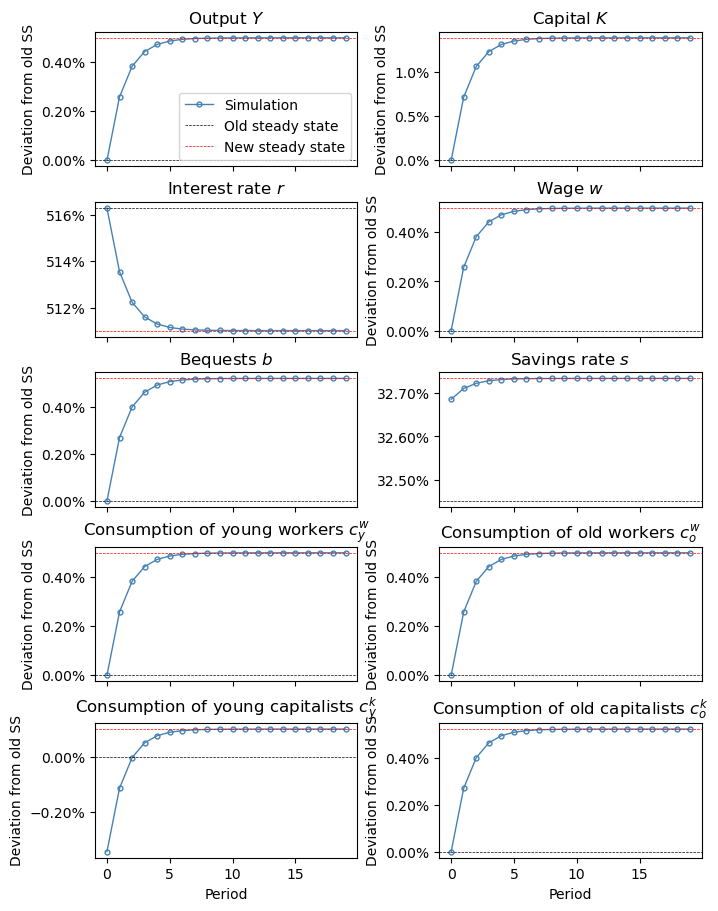

Social welfare (uncertain policy): -29.408


In [16]:
# Steady state with uncertain wealth tax (tau_a=0 today, uncertain tomorrow)
par_wtax_iid = Parameters(tau_a=0.0, tau_a_iid=0.05, pi_a=0.5)
eq_wtax_iid = compute_steady_state(par_wtax_iid, euler_func=euler_err_uncertain)
print_steady_state(eq_wtax_iid)

# Simulate transition
sim_wtax_iid = simulate_olg(eq.K, T, par_wtax_iid, euler_func=euler_err_uncertain)
plot_simulation(eq, sim_wtax_iid, eq_wtax_iid)

# Social welfare comparison
sw_iid = social_welfare(tau_a=0.0, par=par_wtax_iid, euler_func=euler_err_uncertain)
print(f'Social welfare (uncertain policy): {sw_iid:.3f}')